In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

import sys
sys.path.append("../")
from utils_plot import plot_colors

In [2]:
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

In [3]:
lake = 'lucerne'
base_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(base_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(base_path, "outputs_swirl", "ke_eddy")
os.makedirs(output_folder, exist_ok=True)

In [4]:
lvl0_csv_path = os.path.join(input_folder, "lvl0.csv")
lake_csv_path = os.path.join(input_folder, "lake_characteristics.csv")

In [5]:
df_lvl0 = pd.read_csv(lvl0_csv_path)
df_lvl0 = df_lvl0.set_index('id', drop=False)
df_lvl0['date'] = pd.to_datetime(df_lvl0['date'])

In [6]:
df_lake = pd.read_csv(lake_csv_path)
df_lake = df_lake.set_index('id', drop=False)
df_lake['date'] = pd.to_datetime(df_lake['date'])

In [7]:
df_lvl0 = df_lvl0[df_lvl0['date'] >= '2025-03-01']
df_lake = df_lake[df_lake['date'] >= '2025-03-01']

# Spectrum of energy per size

In [8]:

bins = np.arange(0, df_lvl0["surface_area_[m2]"].max() + 500, 10000)

df = df_lvl0[df_lvl0['depth_[m]']>-11].copy()

# Make sure date is datetime and remove invalid dates
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

# Remove invalid surface areas / KE
df = df.dropna(
    subset=["surface_area_[m2]", "kinetic_energy_eddy_[MJ]"]
)

# Bin eddy surface area
df["size_bin"] = pd.cut(
    df["surface_area_[m2]"],
    bins=bins,
    right=False
)

# Use bin centers
df["size_center"] = df["size_bin"].apply(
    lambda x: (x.left + x.right) / 2
)

# Sum KE for each date and size bin
ke = (
    df.groupby(
        ["date", "size_center"],
        observed=True
    )["kinetic_energy_eddy_[MJ]"]
    .sum()
    .unstack("size_center")
    .sort_index()
)

# Remove any remaining invalid dates
ke = ke[ke.index.notna()]

# Make sure the size axis is sorted
ke = ke.sort_index(axis=1)

# Array for smoothing
Z = ke.T.values
Z[np.isnan(Z)] = 0

# Smooth in size and time
lake_ke_surf = df_lake[df_lake['depth_[m]'] > -10].groupby('date').sum()['kinetic_energy_[MJ]']
Z_smooth = gaussian_filter(
    Z,
    sigma=(1.5, 2)
)

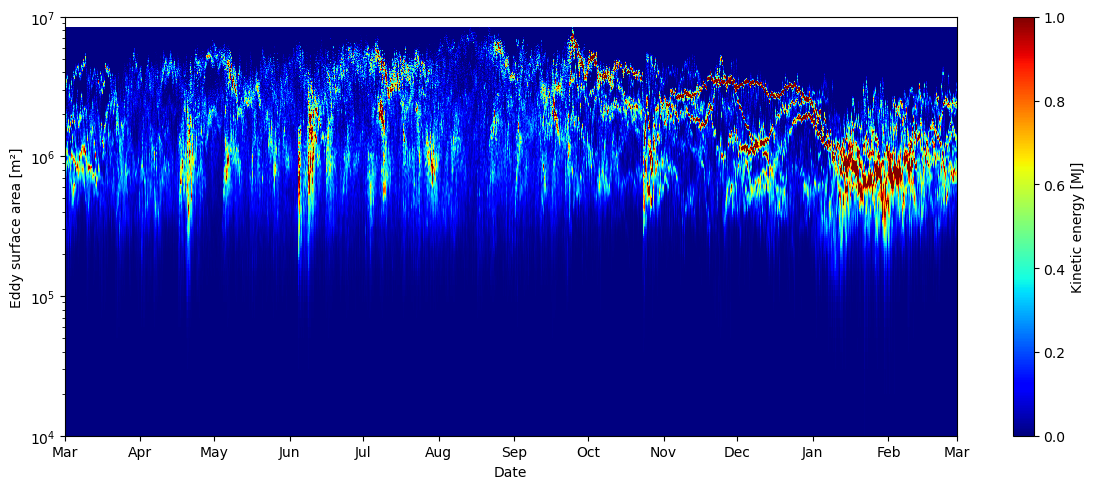

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.pcolormesh(
    ke.index,
    ke.columns,
    Z_smooth,
    shading="auto",
    cmap='jet',
    vmax=1
)

ax.set_xlabel("Date")
ax.set_ylabel("Eddy surface area [m²]")
ax.set_yscale("log")
plt.ylim(1e4, 1e7)

# Format dates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Kinetic energy [MJ]")

plt.tight_layout()
plt.show()

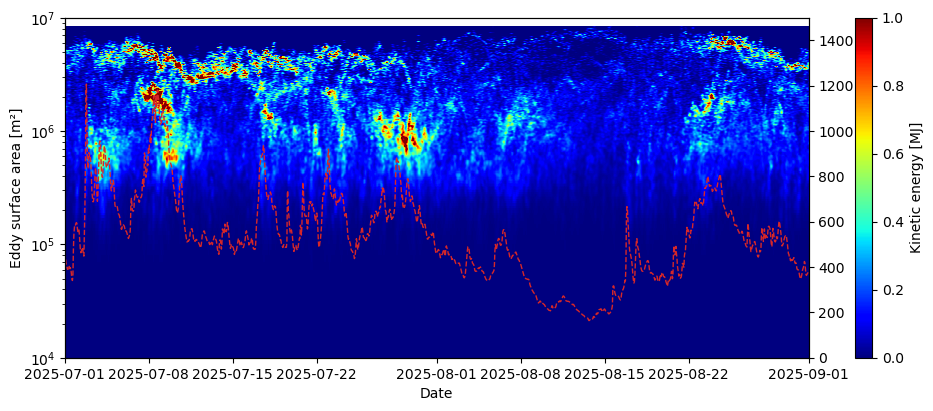

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# =========================
# Heatmap
# =========================
im = ax1.pcolormesh(
    ke.index,
    ke.columns,
    Z_smooth,
    shading="auto",
    cmap="jet",
    vmax=1
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Eddy surface area [m²]")
ax1.set_yscale("log")
ax1.set_ylim(1e4, 1e7)

# =========================
# Total KE as line
# =========================
ax2 = ax1.twinx()

lake_ke_surf.plot(
    ax=ax2,
    linewidth=1,
    ls='--',
    color='tab:red'
)

ax2.set_ylabel("Total kinetic energy [MJ]")
ax2.set_ylim(0, 1500)

# =========================
# Date formatting
# =========================
ax1.set_xlim(
    pd.Timestamp("2025-07-01"),
    pd.Timestamp("2025-09-01")
)

#ax1.xaxis.set_major_locator(mdates.MonthLocator())
#ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Colorbar
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Kinetic energy [MJ]")

#plt.tight_layout()
plt.show()

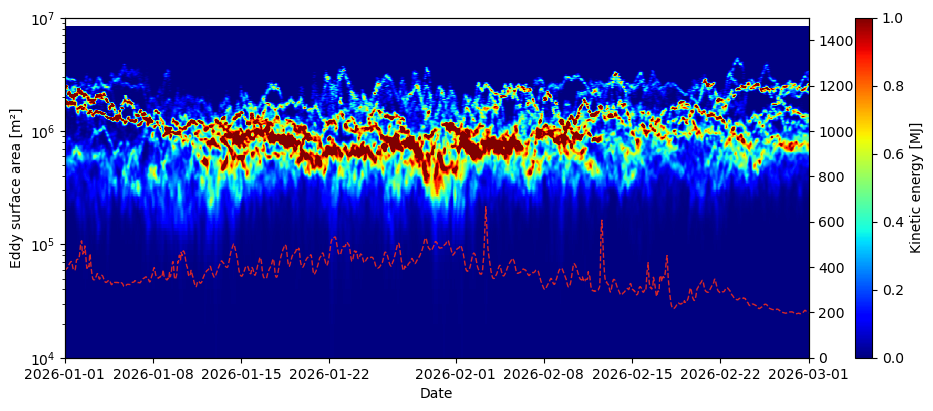

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# =========================
# Heatmap
# =========================
im = ax1.pcolormesh(
    ke.index,
    ke.columns,
    Z_smooth,
    shading="auto",
    cmap="jet",
    vmax=1
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Eddy surface area [m²]")
ax1.set_yscale("log")
ax1.set_ylim(1e4, 1e7)

# =========================
# Total KE as line
# =========================
ax2 = ax1.twinx()

lake_ke_surf.plot(
    ax=ax2,
    linewidth=1,
    ls='--',
    color='tab:red'
)

ax2.set_ylabel("Total kinetic energy [MJ]")
ax2.set_ylim(0, 1500)

# =========================
# Date formatting
# =========================
ax1.set_xlim(
    pd.Timestamp('2026-01-01'), 
    pd.Timestamp('2026-03-01')
)

#ax1.xaxis.set_major_locator(mdates.MonthLocator())
#ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Colorbar
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Kinetic energy [MJ]")

#plt.tight_layout()
plt.show()